# FTL099 - Inteligência Artificial Aplicada  
Aluno: Nycksandro Lima dos Santos  
Matrícula: 22351228  

# Trabalho 06 - Redes Recorrentes

## Objetivo

Esse trabalho tem por objetivo a identificação de atividades a partir dos sinais x, y e z de acelerômetros,
contidos no dispositivo móvel Samsung Galaxy Nexus I9250 com o sistema operacional Android versão 5.1.1,
equipado com o sensor de aceleração Bosh BMA220. Esses dados foram coletados a partir da base de dados
UniMibSHAR [1] e contém informações de aceleração das seguintes atividades:
1. Levantando a partir de um estado sentado numa cadeira – ‘StandingUpFS'
2. Levantando a partir de um estado deitado na cama - 'StandingUpFL'
3. Caminhando - 'Walking'
4. Correndo - 'Running'
5. Descendo uma escada - 'GoingUpS'
6. Pulando - 'Jumping'
7. Subindo uma escada - 'GoingDownS'
8. Deitando numa cama a partir de um estado em pé - 'LyingDownFS'
9. Sentando numa cadeira estando em pé - 'SittingDown'

## Importando bibliotecas

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Carregando as base de dados

In [ ]:
# Carregando data
dados = pd.read_csv('/content/dados.csv', header=None)

# Carregando as labels
labels = pd.read_csv('/content/labels.csv', header=None)


## Formato dos dados

In [ ]:
print(f"Formato da base dados: {dados.shape}") # Data
print(f"Formato da base labels: {labels.shape}") # Labels

Formato da base dados: (1724, 453)
Formato da base labels: (1724, 1)


## Reorganizando para LSTM

In [ ]:
x_axis = dados.iloc[:, 0:151]
y_axis = dados.iloc[:, 151:302]
z_axis = dados.iloc[:, 302:453]

In [ ]:
X = np.stack((x_axis, y_axis, z_axis), axis=2)
print("Formato para LSTM:", X.shape)

# Formato final:
# (amostras, timesteps, features)


Formato para LSTM: (1724, 151, 3)


In [ ]:
y = labels - 1 # Classes de 1-9 para 0-8

In [ ]:
y_cat = to_categorical(y, num_classes=9) # One-hot encoding

## Divisão dos dados

In [ ]:
# Conjunto de treinamento: 85% dos dados
# Conjunto de validação: 15% dos dados
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_cat,
    test_size=0.15,
    random_state=42,
    stratify=y
)

In [ ]:
print("Treino:", X_train.shape)
print("Validação:", X_val.shape)

Treino: (1465, 151, 3)
Validação: (259, 151, 3)


## Carregando o Modelo

In [ ]:
model = Sequential()

model.add(
    LSTM(
        units=64,
        input_shape=(151, 3))
)

model.add(Dropout(0.3))

model.add(Dense(
    32,
    activation='relu'
))

model.add(Dense(
    9,
    activation='softmax'
))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


### Arquitetura da rede

In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 9)              │           297 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,785 (77.29 KB)

 Trainable params: 19,785 (77.29 KB)

 Non-trainable params: 0 (0.00 B)

## Compilação

In [ ]:
model.compile(
    optimizer= Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## Treinamento

In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1)

Epoch 1/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.2642 - loss: 1.9615 - val_accuracy: 0.3166 - val_loss: 1.7571
Epoch 2/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.3372 - loss: 1.7289 - val_accuracy: 0.3514 - val_loss: 1.6027
Epoch 3/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4471 - loss: 1.5272 - val_accuracy: 0.5174 - val_loss: 1.3192
Epoch 4/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5024 - loss: 1.3067 - val_accuracy: 0.5483 - val_loss: 1.1203
Epoch 5/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.5474 - loss: 1.1415 - val_accuracy: 0.5714 - val_loss: 1.0043
Epoch 6/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5802 - loss: 1.0518 - val_accuracy: 0.6409 - val_loss: 0.9066
Epoch 7/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6362 - loss: 0.9237 - val_accuracy: 0.6602 - val_loss: 0.8279
Epoch 8/50
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6451 - loss: 0.9114 - val_accuracy: 0.6718 - v

## Resultados

### Curva de treinamento



#### Acurácia

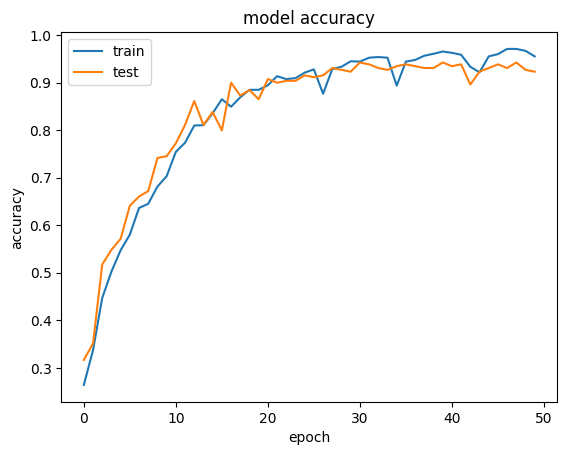

In [ ]:
# summarize history for accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

#### Perda ao longo do treinamento




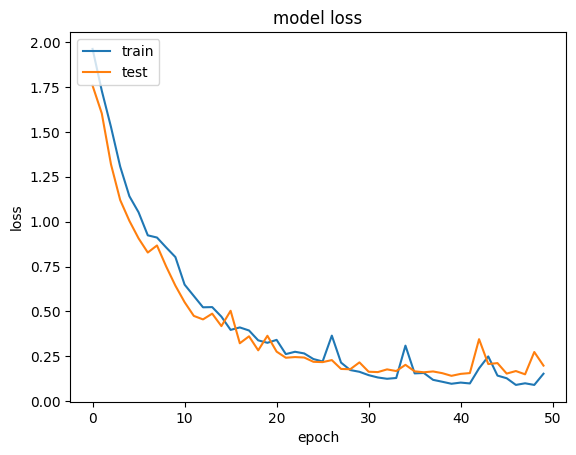

In [ ]:
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

### O valor da acurácia obtida no conjunto de validação (superior a 85%)


In [ ]:
loss, acc = model.evaluate(X_val, y_val)
print(f"Loss: {loss}")
print(f"Acurácia: {acc}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9228 - loss: 0.1984
Loss: 0.1983884871006012
Acurácia: 0.92277991771698


In [ ]:
# predictions
y_pred_prob = model.predict(X_val)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_val, axis=1)

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step


### Tabela de confusão obtida a partir da classificação dos dados no conjunto de validação

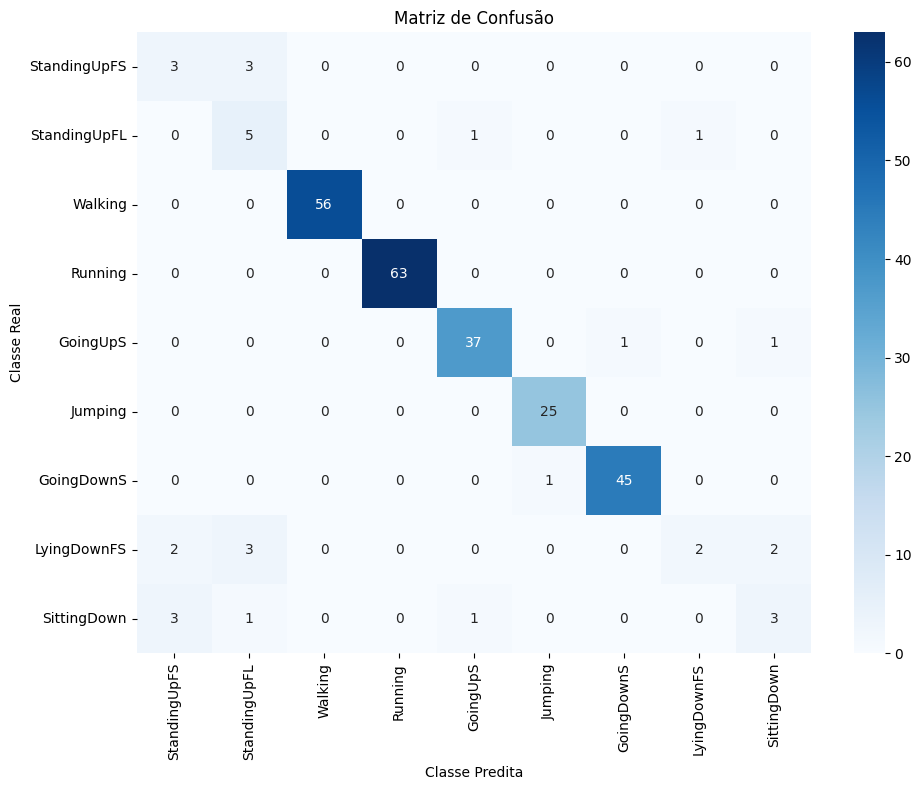

In [ ]:
classes = [
    "StandingUpFS",
    "StandingUpFL",
    "Walking",
    "Running",
    "GoingUpS",
    "Jumping",
    "GoingDownS",
    "LyingDownFS",
    "SittingDown"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)

plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.title("Matriz de Confusão")

plt.tight_layout()
plt.show()

In [ ]:
print("\nRelatório de Classificação:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=classes
    )
)


Relatório de Classificação:

              precision    recall  f1-score   support

StandingUpFS       0.38      0.50      0.43         6
StandingUpFL       0.42      0.71      0.53         7
     Walking       1.00      1.00      1.00        56
     Running       1.00      1.00      1.00        63
    GoingUpS       0.95      0.95      0.95        39
     Jumping       0.96      1.00      0.98        25
  GoingDownS       0.98      0.98      0.98        46
 LyingDownFS       0.67      0.22      0.33         9
 SittingDown       0.50      0.38      0.43         8

    accuracy                           0.92       259
   macro avg       0.76      0.75      0.74       259
weighted avg       0.93      0.92      0.92       259



## Pesos finais

In [ ]:
for layer in model.layers:
    pesos = layer.get_weights()

    if len(pesos) > 0:
        print(f"\n{layer.name}")

        for p in pesos:
            print(
                f"shape={p.shape} "
                f"min={p.min():.4f} "
                f"max={p.max():.4f} "
                f"mean={p.mean():.4f}"
            )


lstm
shape=(3, 256) min=-0.3858 max=0.3826 mean=0.0090
shape=(64, 256) min=-0.7389 max=0.5515 mean=-0.0000
shape=(256,) min=-0.2005 max=1.2608 mean=0.2978

dense
shape=(64, 32) min=-0.8284 max=0.7888 mean=0.0161
shape=(32,) min=-0.0035 max=0.5809 mean=0.1584

dense_1
shape=(32, 9) min=-0.8274 max=0.5800 mean=-0.0741
shape=(9,) min=-0.0518 max=0.0581 mean=-0.0048
